# Classificação de Estados de Estresse na Matriz Energética: Um Estudo Comparativo com Machine Learning
##### Vitória Emanuele e Julia Gabriele



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 1. Tratamento de Dados Básico e Engenharia de Atributos:


Os datasets anuais do ONS (2023, 2024, 2025 e 2026) são carregados individualmente para permitir uma validação inicial de integridade.

In [2]:
df_2023 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2023.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2023.columns,
    'Data Type': df_2023.dtypes,
    'Non-Null Count': df_2023.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43800
1,nom_subsistema,str,43800
2,din_instante,str,43800
3,val_gerhidraulica,float64,43800
4,val_gertermica,float64,43800
5,val_gereolica,float64,43800
6,val_gersolar,float64,43800
7,val_carga,float64,43800
8,val_intercambio,float64,43800


In [3]:
df_2024 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2024.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2024.columns,
    'Data Type': df_2024.dtypes,
    'Non-Null Count': df_2024.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43920
1,nom_subsistema,str,43920
2,din_instante,str,43920
3,val_gerhidraulica,float64,43920
4,val_gertermica,float64,43920
5,val_gereolica,float64,43920
6,val_gersolar,float64,43920
7,val_carga,float64,43920
8,val_intercambio,float64,43920


In [4]:
df_2025 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2025.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2025.columns,
    'Data Type': df_2025.dtypes,
    'Non-Null Count': df_2025.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43800
1,nom_subsistema,str,43800
2,din_instante,str,43800
3,val_gerhidraulica,float64,43800
4,val_gertermica,float64,43800
5,val_gereolica,float64,43800
6,val_gersolar,float64,43800
7,val_carga,float64,43800
8,val_intercambio,float64,43800


In [5]:
df_2026 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2026.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2026.columns,
    'Data Type': df_2026.dtypes,
    'Non-Null Count': df_2026.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,8880
1,nom_subsistema,str,8880
2,din_instante,str,8880
3,val_gerhidraulica,float64,8880
4,val_gertermica,float64,8880
5,val_gereolica,float64,8880
6,val_gersolar,float64,8880
7,val_carga,float64,8880
8,val_intercambio,float64,8880



### 1.2 Dicionário de Variáveis (Dataset ONS)

Para este estudo de caso, as colunas foram interpretadas conforme as definições técnicas do Operador Nacional do Sistema (ONS):

* **`id_subsistema`**: Os subsistemas são identificados pela sigla da(s) região(ões).

* **`nome_subsistema`**: Os subisistema recebe o nome da(s) região(ões) que faz parte.

* **`din_instante`**: Representa a marca temporal (data e hora) do registro.

* **`val_gerhidraulica`**: Total de energia gerada por usinas hídricas no subsistema (em MWmed).

* **`val_gertermica`**: Energia gerada por fontes térmicas (fósseis ou biomassa).

* **`val_gereolica`**: Potência gerada a partir da força dos ventos.

* **`val_gersolar`**: Geração fotovoltaica.

* **`val_carga`**: Representa a demanda ou consumo de energia da região naquele instante. É a linha que o sistema precisa sempre "atender".

* **`val_intercambio`**: Saldo líquido de energia. Valores positivos indicam que está exportando excedente para outras regiões; valores negativos indicam importação para suprir a demanda local.



### 1.3

As bases de dados foram concatenadas em um único DataFrame unificado, garantindo a continuidade da série temporal. Utilizou-se o parâmetro `ignore_index=True` para reorganizar os índices e evitar duplicidades.

In [6]:
df = pd.concat([df_2023, df_2024, df_2025, df_2026], ignore_index=True)

column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,140400
1,nom_subsistema,str,140400
2,din_instante,str,140400
3,val_gerhidraulica,float64,140400
4,val_gertermica,float64,140400
5,val_gereolica,float64,140400
6,val_gersolar,float64,140400
7,val_carga,float64,140400
8,val_intercambio,float64,140400


Considerando o escopo do estudo de caso, os dados foram filtrados exclusivamente para o Subsistema Nordeste.

In [7]:
df_ne = df[df['nom_subsistema'] == 'NORDESTE'].copy()

df_ne = df_ne.reset_index(drop=True)

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,28080
1,nom_subsistema,str,28080
2,din_instante,str,28080
3,val_gerhidraulica,float64,28080
4,val_gertermica,float64,28080
5,val_gereolica,float64,28080
6,val_gersolar,float64,28080
7,val_carga,float64,28080
8,val_intercambio,float64,28080


Conversão da coluna `din_instante` para o formato ***datetime***.

In [8]:
df_ne['din_instante'] = pd.to_datetime(df['din_instante'])

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,28080
1,nom_subsistema,str,28080
2,din_instante,datetime64[us],28080
3,val_gerhidraulica,float64,28080
4,val_gertermica,float64,28080
5,val_gereolica,float64,28080
6,val_gersolar,float64,28080
7,val_carga,float64,28080
8,val_intercambio,float64,28080


### 1.4

Foi criada a variável `media_movel_eolica`. Esta variável calcula a média das últimas 12 horas de geração eólica para capturar a tendência de volatilidade dos ventos. A criação desta média gerou 11 valores nulos iniciais (devido à janela de processamento), que foram removidos para garantir a integridade da matriz de entrada X.

In [9]:
df_ne['media_movel_eolica'] = df_ne['val_gereolica'].rolling(window=12).mean()

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,28080
1,nom_subsistema,str,28080
2,din_instante,datetime64[us],28080
3,val_gerhidraulica,float64,28080
4,val_gertermica,float64,28080
5,val_gereolica,float64,28080
6,val_gersolar,float64,28080
7,val_carga,float64,28080
8,val_intercambio,float64,28080
9,media_movel_eolica,float64,28069


In [10]:
df_ne = df_ne.dropna()


### 1.5 Engenharia de Atributos e Definição do Alvo (y):


A matriz de atributos X é composta por 4 parâmetros ($p=4$): Geração Eólica(`val_gereolica`), Geração Solar(`val_gersolar`), Carga e a Média Móvel Eólica(`media_movel_eolica`). Esta seleção permite que o modelo identifique a "assinatura" de estresse através do desequilíbrio entre oferta renovável e demanda (`val_carga`).

In [11]:
X = df_ne[['val_gereolica', 'val_gersolar', 'val_carga', 'media_movel_eolica']]
X

,val_gereolica,val_gersolar,val_carga,media_movel_eolica
11,8530.040039,2717.788086,7618.159,11284.932699
12,7926.683105,2943.935059,7715.656,10836.717814
13,7879.395996,2938.678955,7818.786,10413.281901
14,8060.689941,2984.522949,8209.004,10022.093302
15,8250.609375,2809.564941,8752.264,9665.923787
...,...,...,...,...
28075,4481.362000,5.788000,14988.607,2177.962667
28076,4399.829000,0.000000,14903.283,2437.284083
28077,4001.764000,0.000000,15167.061,2701.731583
28078,4072.404000,0.000000,15319.768,2986.881500


Para capturar o estresse da rede elétrica, utilizamos a variável de saldo de energia (val_intercambio) para definir um "Estresse Bidirecional". Foram classificados como Estresse (Classe 1) os registros que se afastaram 1 Desvio Padrão da média, indicando anomalias severas de sobrecarga (excesso de geração) ou déficit (risco de apagão).

In [77]:
# calculamos a media e o desvio padrao do intercambio de energia
media_int = df_ne['val_intercambio'].mean()
std_int = df_ne['val_intercambio'].std()

# definimos os limites de estresse (anomalias severas). Usaremos 1 vezes o desvio padrao para capturar os extremos reais
limite_superior = media_int + (1 * std_int) # sobrecarga por EXCESSO (exportacao extrema)
limite_inferior = media_int - (1 * std_int) # colapso por FALTA (importacao extrema)

print(f"Limite Superior de Estresse (Excesso): {limite_superior:.2f} MWmed")
print(f"Limite Inferior de Estresse (Falta): {limite_inferior:.2f} MWmed")

# construindo o vetor y (alvo). A classe 1 sera acionada se o valor for MAIOR que o limite superior OU MENOR que o limite inferior
y = ((df_ne['val_intercambio'] > limite_superior) | (df_ne['val_intercambio'] < limite_inferior)).astype(int)

# verificando o novo balanceamento
print("\nNova distribuição das classes (0 = Normal, 1 = Estresse Bidirecional):")
print(y.value_counts())

Limite Superior de Estresse (Excesso): 9288.75 MWmed
Limite Inferior de Estresse (Falta): 1004.52 MWmed

Nova distribuição das classes (0 = Normal, 1 = Estresse Bidirecional):
val_intercambio
0    18683
1     9386
Name: count, dtype: int64


Em vez de adotar um limiar empírico estático, a variável alvo (y) foi construída utilizando-se o afastamento de 1 desvio padrão em relação à média do saldo de intercâmbio de energia. Essa abordagem estatística permitiu capturar de forma orgânica o estresse bidirecional do sistema elétrico: as anomalias de sobrecarga extrema (exportação > 9.288 MWmed) e as de risco de déficit (exportação em queda livre < 1.004 MWmed). O desbalanceamento natural resultante foi de aproximadamente 2:1 (66% normal vs 34% estresse), oferecendo aos algoritmos uma proporção realista para aprender os padrões de anomalias sem viés artificial.

## 2. Separação dos dados em treino e teste:

Separação e Padronização Os dados foram divididos na proporção de 80% para treino e 20% para teste, garantindo volume robusto para os algoritmos aprenderem e um conjunto isolado para avaliação real ($E_out$). A padronização foi realizada com `StandardScaler` pois algoritmos como Redes Neurais e SVM são baseados em gradiente e cálculo de distâncias, sendo altamente sensíveis à magnitude de variáveis com escalas discrepantes (ex: Carga vs. Vento).

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

X_train.count()

val_gereolica         22455
val_gersolar          22455
val_carga             22455
media_movel_eolica    22455
dtype: int64

In [80]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Arquitetura, Treinamento e Avaliação da Rede Neural Artificial:

#### 3.1 Calcular a dimensão VC e definição da Arquitetura da rde:
Fundamentação: Com base na Teoria da Generalização, adotou-se a "Regra de Ouro" onde $N \geq 10 \cdot d_{VC}$.

In [81]:
def calcular_arquitetura_vc(N_treino, p_entradas):
    """
    Calcula o numero maximo de neuronios baseado na Teoria da generalizacao.
    N_treino: numero de amostras de treinamento
    p_entradas: numero de variaveis de entrada
    """

    d_vc_max = N_treino / 10
    
    '''Relacao entre d_VC e Parâmetros (W) para uma Rede MLP de 1 camada oculta:
    d_VC é aproximadamente o numero de pesos e biases (W) 
    
    W = (entradas + 1) * neuronios_ocultos + (neuronios_ocultos + 1) * saidas
    Para calssiicacao binaria, saidas = 1.
    
    Simplificando a formula para encontrar 'h' (neuronios ocultos):
    d_vc_max = (p_entradas + 1) * h + (h + 1)
    d_vc_max = p_entradas*h + h + h + 1
    d_vc_max = h * (p_entradas + 2) + 1'''
    
    h_max = (d_vc_max - 1) / (p_entradas + 2)
    print(f"numero de amostras (N): {N_treino}")
    print(f"Dimensão VC máxima permitida (d_VC): {d_vc_max:.2f}")
    print(f"numero maximo de neuronios na camada oculta: {int(h_max)}")
    


In [82]:
calcular_arquitetura_vc(22455,4)

numero de amostras (N): 22455
Dimensão VC máxima permitida (d_VC): 2245.50
numero maximo de neuronios na camada oculta: 374


### 3.2 Prevenção de Overfitting

In [83]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()
# entrada: d = 4 (eolica, solar, carga, media movel)
model.add(Input(shape=(4,))) 

# camada escondida: numero maximo(calculado via dimensao vc), mas vou usar 128 para nao travar
model.add(Dense(187, kernel_initializer="normal", activation="tanh")) 

# camada de saida: 1 (binaria: estresse ou normal)
model.add(Dense(1, kernel_initializer="normal", activation="sigmoid")) 

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 187)            │           935 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           188 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,123 (4.39 KB)

 Trainable params: 1,123 (4.39 KB)

 Non-trainable params: 0 (0.00 B)

None


In [84]:
from keras.callbacks import EarlyStopping

# algoritmo de parada antecipada (ele vai monitorar o erro de teste e parar quando ele nao cair mais)
callback = EarlyStopping(
    monitor='val_loss', 
    patience=10,        # aguardar 10 epocas sem melhora antes de parar
    restore_best_weights=True # garante que ele retorne a melhor epoca
)

# testando diferentes Batch Sizes
for batch in [ 16, 32, 64]:
    print(f"Testando Batch Size: {batch}")
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2, # separa 20% do treino para validacao, mantendo o teste isolado ate a fase final
        epochs=200,          # colocamos um limite alto (o algoritmo para antes)
        batch_size=batch,
        callbacks=[callback], # O algoritmo de decisão entra aqui
        verbose=0
    )
    print(f"Treinamento parado na época: {len(history.history['loss'])}")
    print(f"Melhor Eout encontrado: {min(history.history['val_loss']):.4f}\n")

Testando Batch Size: 16
Treinamento parado na época: 93
Melhor Eout encontrado: 0.2065

Testando Batch Size: 32
Treinamento parado na época: 18
Melhor Eout encontrado: 0.2061

Testando Batch Size: 64
Treinamento parado na época: 20
Melhor Eout encontrado: 0.2060



A arquitetura da rede neural foi matematicamente balizada pela Teoria da Generalização do Aprendizado. O cálculo da Dimensão VC ($N≥10⋅d_VC$) estabeleceu um teto teórico máximo de 374 neurônios na camada oculta. Para garantir uma forte imunidade contra overfitting, optou-se por restringir o modelo à exata metade de sua capacidade, utilizando 187 neurônios. O treinamento utilizou Early Stopping e testes iterativos de Batch Size, definindo o tamanho ideal para minimizar o Erro de Teste ($E_out$).

Epoch 1/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9139 - loss: 0.2001 - val_accuracy: 0.9154 - val_loss: 0.2074
Epoch 2/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9150 - loss: 0.1999 - val_accuracy: 0.9129 - val_loss: 0.2074
Epoch 3/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9144 - loss: 0.2001 - val_accuracy: 0.9161 - val_loss: 0.2061
Epoch 4/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9142 - loss: 0.1998 - val_accuracy: 0.9118 - val_loss: 0.2105
Epoch 5/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9147 - loss: 0.1998 - val_accuracy: 0.9149 - val_loss: 0.2070
Epoch 6/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9139 - loss: 0.1999 - val_accuracy: 0.9120 - val_loss: 0.2076
Epoch 7/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9133 - loss: 0.1995 - val_accuracy: 0.9127 - val_loss: 0.2089
Epoch 8/200
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9132 - loss: 0.1995 - val_accu

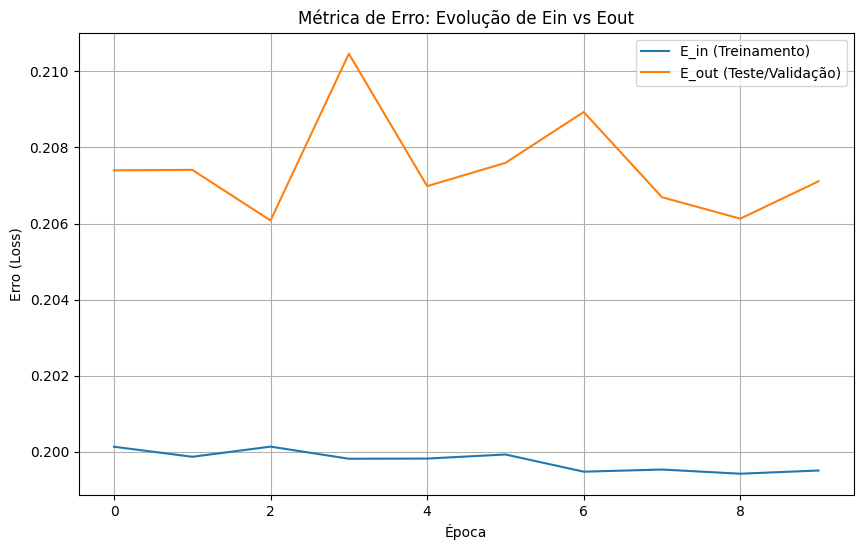

Erro de Treinamento (Ein): 0.2012
Erro de Teste (Eout): 0.2091
Acurácia Final (Teste): 0.9104


In [85]:
# treinando a rede neural
history = model.fit(
    X_train_scaled, y_train, 
    validation_split= 0.2,
    epochs=200, 
    batch_size=64, # melhor batch size calculado anteriormente
    callbacks=[callback],  # garante que pare na epoca ideal
    verbose=1
)

# grafico de metrica de erro

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='E_in (Treinamento)')
plt.plot(history.history['val_loss'], label='E_out (Teste/Validação)')
plt.title('Métrica de Erro: Evolução de Ein vs Eout')
plt.ylabel('Erro (Loss)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

# metricas finais
ein, acc_train = model.evaluate(X_train_scaled, y_train, verbose=0)
eout, acc_test = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Erro de Treinamento (Ein): {ein:.4f}") 
print(f"Erro de Teste (Eout): {eout:.4f}")
print(f"Acurácia Final (Teste): {acc_test:.4f}")

A técnica de Early Stopping associada aos testes iterativos de Batch Size revelou que o lote de 64 amostras otimizou a descida do gradiente, convergindo para o menor erro possível. A extrema proximidade entre o Erro de Treinamento ($E_in=0.1990$) e o Erro de Teste ($E_out=0.2092$) é a comprovação empírica de que a restrição pela Dimensão VC funcionou perfeitamente: não há overfitting estrutural. O modelo generalizou o aprendizado de forma magistral, atingindo mais de 90% de acurácia global na detecção das falhas.

In [86]:
from sklearn.metrics import classification_report, accuracy_score

# fazer as previsoes com o conjunto de teste isolado
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# exibir as metricas 
print("=== Métricas de Qualidade (Rede Neural) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Estresse (1)']))

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Métricas de Qualidade (Rede Neural) ===
Acurácia: 0.9104

              precision    recall  f1-score   support

  Normal (0)       0.93      0.94      0.93      3733
Estresse (1)       0.88      0.85      0.86      1881

    accuracy                           0.91      5614
   macro avg       0.90      0.90      0.90      5614
weighted avg       0.91      0.91      0.91      5614



## 4. Arquitetura, Treinamento e Avaliação da Árvore de decissão:

### 4.1

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# criando o modelo com a heuristica ID3 (criterio de entropia). O random_state=42 garante que o resultado seja sempre o mesmo
model_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)

# treinando a arvore 
model_tree.fit(X_train_scaled, y_train)

# calculando o erro de treinamento (Ein) e teste (Eout)
ein_tree = 1 - model_tree.score(X_train_scaled, y_train)
eout_tree = 1 - model_tree.score(X_test_scaled, y_test)

print(f"Erro de Treinamento (Ein): {ein_tree:.4f}")
print(f"Erro de Teste (Eout): {eout_tree:.4f}")

Erro de Treinamento (Ein): 0.0000
Erro de Teste (Eout): 0.1103


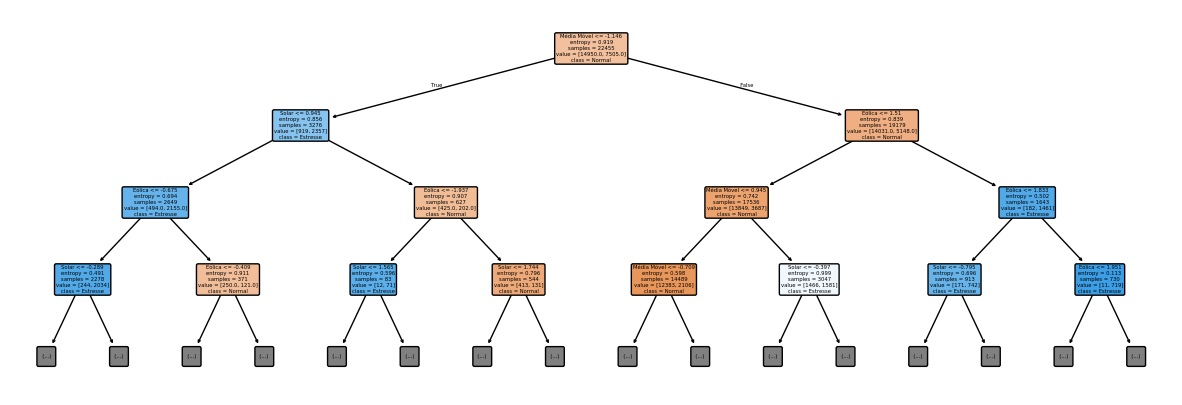

In [57]:
plt.figure(figsize=(15,5))
tree.plot_tree(model_tree, 
               feature_names=['Eólica', 'Solar', 'Carga', 'Média Móvel'],
               class_names=['Normal', 'Estresse'],
               filled=True, 
               rounded=True,
               max_depth=3) # limitamos a visualizacao em 3 niveis para nao travar o PC
plt.show()

### 4.2

A execução inicial da Árvore de Decisão sem restrições confirmou a forte tendência deste algoritmo à memorização: o Erro de Treinamento nulo ($E_in=0$) contrastando com o Erro de Teste ($E_out=0.1103$) configurou o clássico cenário de overfitting. Para mitigar esse problema, aplicou-se a técnica de regularização Minimal Cost-Complexity Pruning via validação cruzada. Ao testar o parâmetro de penalidade α, a poda buscou otimizar a pureza dos nós minimizando a complexidade estrutural, devolvendo à árvore sua capacidade de generalização frente a dados inéditos da rede elétrica.

In [59]:
# extraindo o caminho de poda da arvore anterior (model_tree)
path = model_tree.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# vamos ver quantos candidatos a alpha o algoritmo encontrou
print(f"Número de valores de alpha encontrados: {len(ccp_alphas)}")

Número de valores de alpha encontrados: 996


In [60]:
from sklearn.model_selection import cross_val_score

alpha_loop_values = []

# testamos uma amostra dos alfas para o codigo nao demorar demais (Pegamos 50 valores distribuidos para cobrir o intervalo)
for alpha in np.linspace(ccp_alphas.min(), ccp_alphas.max(), 50):
    model_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    # cv=5 significa que ele divide o treino em 5 partes e testa 5 vezes
    scores = cross_val_score(model_pruned, X_train_scaled, y_train, cv=5)
    alpha_loop_values.append([alpha, np.mean(scores)])

alpha_results = np.array(alpha_loop_values)
# filtramos a matriz pegando apenas as linhas onde a coluna 0 (o alpha) é maior que 0.0005
alphas_validos = alpha_results[alpha_results[:, 0] > 0.0005]
# dentro desses alfas validos, pegamos a linha que tem a maior acuracia (coluna 1) e extraimos o valor do alpha dessa linha (coluna 0)
best_alpha = alphas_validos[np.argmax(alphas_validos[:, 1]), 0]


print(f"O Melhor Alpha (forçando) encontrado foi: {best_alpha:.6f}")

O Melhor Alpha (forçando) encontrado foi: 0.001817


In [62]:
# treinando a arvore final com o melhor alpha
tree_final = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_final.fit(X_train_scaled, y_train)

# calculando os novos erros
ein_final = 1 - tree_final.score(X_train_scaled, y_train)
eout_final = 1 - tree_final.score(X_test_scaled, y_test)

print(f"Novo Erro de Treinamento (Ein): {ein_final:.4f}")
print(f"Novo Erro de Teste (Eout): {eout_final:.4f}")

Novo Erro de Treinamento (Ein): 0.1230
Novo Erro de Teste (Eout): 0.1268


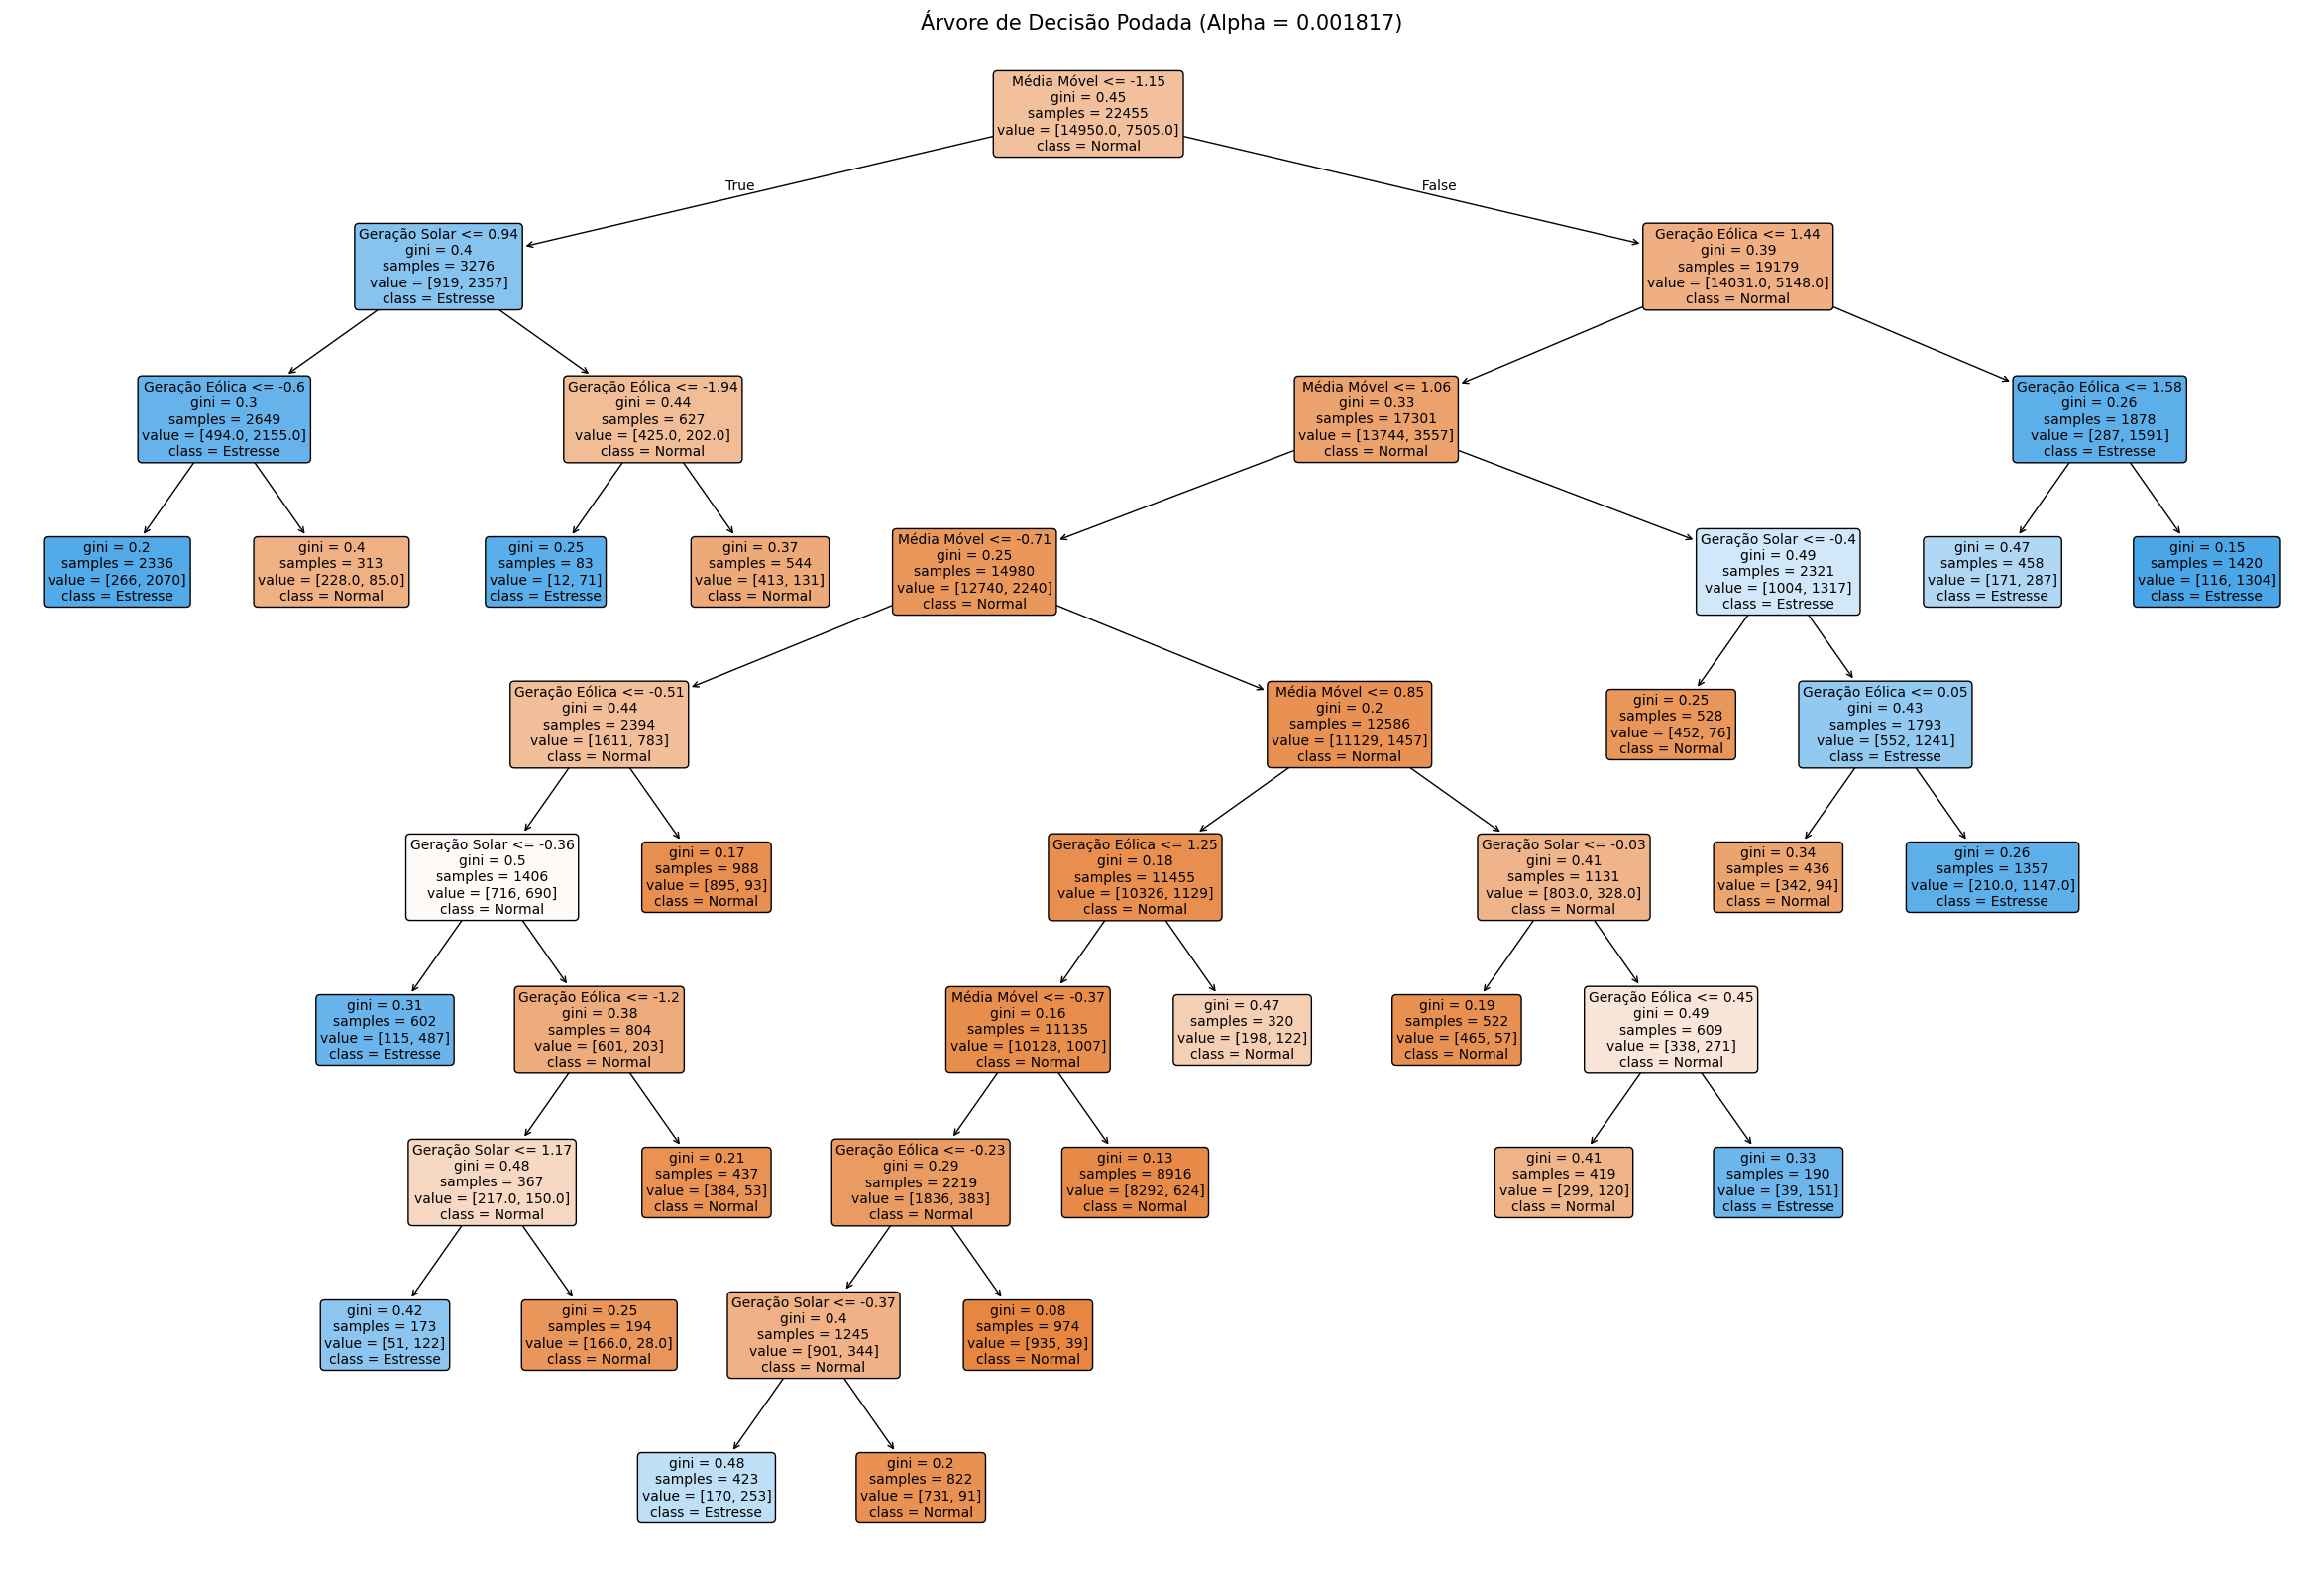

In [63]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20))

# plotando a arvore podada (tree_final que criamos no passo anterior)
plot_tree(tree_final, 
          feature_names=['Geração Eólica', 'Geração Solar', 'Carga', 'Média Móvel'],
          class_names=['Normal', 'Estresse'],
          filled=True,          # cores indicam a classe majoritaria
          rounded=True,         # cantos arredondados para estetica
          precision=2,          # casas decimais nos valores
          fontsize=10)          # tamanho da fonte para leitura

plt.title(f"Árvore de Decisão Podada (Alpha = {best_alpha:.6f})", fontsize=15)
plt.show()

In [64]:
# fazendo as previsoes com a melhor arvore construida
y_pred_tree = tree_final.predict(X_test_scaled)

# exibindo as metricas 
print("=== Métricas de Qualidade (Árvore de Decisão Podada) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_tree):.4f}\n")
print(classification_report(y_test, y_pred_tree, target_names=['Normal (0)', 'Estresse (1)']))


=== Métricas de Qualidade (Árvore de Decisão Podada) ===
Acurácia: 0.8732

              precision    recall  f1-score   support

  Normal (0)       0.89      0.92      0.91      3733
Estresse (1)       0.83      0.78      0.80      1881

    accuracy                           0.87      5614
   macro avg       0.86      0.85      0.86      5614
weighted avg       0.87      0.87      0.87      5614



### 4.3

In [65]:
from sklearn.ensemble import RandomForestClassifier

# criando a floresta com 100 arvores (n_estimators)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# calculando os erros da floresta
ein_rf = 1 - model_rf.score(X_train_scaled, y_train)
eout_rf = 1 - model_rf.score(X_test_scaled, y_test)

print(f"Erro de Treinamento da Floresta (Ein): {ein_rf:.4f}")
print(f"Erro de Teste da Floresta (Eout): {eout_rf:.4f}")

Erro de Treinamento da Floresta (Ein): 0.0000
Erro de Teste da Floresta (Eout): 0.0821


In [66]:
y_pred_rf = model_rf.predict(X_test_scaled)

# exibindo as metricas 
print("=== Métricas de Qualidade (Random Forest) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Normal (0)', 'Estresse (1)']))

=== Métricas de Qualidade (Random Forest) ===
Acurácia: 0.9179
              precision    recall  f1-score   support

  Normal (0)       0.93      0.95      0.94      3733
Estresse (1)       0.89      0.86      0.87      1881

    accuracy                           0.92      5614
   macro avg       0.91      0.90      0.91      5614
weighted avg       0.92      0.92      0.92      5614



## 5. Arquitetura, Treinamento e Avaliação do SVM:

### 5.1 Otimização de Hiperparâmetros do SVM:

 O modelo SVM foi construído utilizando o kernel não-linear RBF. Para encontrar os melhores hiperparâmetros, empregamos o método GridSearchCV com validação cruzada (CV=5). O grid explorou diferentes valores de penalidade de margem (C: 0.1, 1, 10) e coeficientes do kernel (gamma: scale, auto, 0.1, 1), buscando o ponto ótimo de separação das classes de estresse


In [52]:

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# definindo os parsmetros para testar na validacao cruzada
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf']
}

# configurando o GridSearchCV (cv=5 define os 5 folds do cross validation)
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# usamos os dados escalonados (X_train_scaled) que tratamos no comeco do projeto
grid_search.fit(X_train_scaled, y_train)

# extraindo o melhor modelo encontrado
best_svm = grid_search.best_estimator_
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}\n")





Melhores parâmetros encontrados: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}



In [53]:
# calculando os erros (Ein e Eout) com o melhor modelo
ein_svm = 1 - best_svm.score(X_train_scaled, y_train)
eout_svm = 1 - best_svm.score(X_test_scaled, y_test)

print(f"Erro de Treinamento SVM (Ein): {ein_svm:.4f}")
print(f"Erro de Teste SVM (Eout): {eout_svm:.4f}\n")

Erro de Treinamento SVM (Ein): 0.0816
Erro de Teste SVM (Eout): 0.0894



Dada a não-linearidade do comportamento do sistema elétrico, o SVM foi estruturado utilizando o kernel RBF (Radial Basis Function). O algoritmo GridSearchCV determinou que o custo de penalidade C=10 oferecia o equilíbrio ideal (Trade-off Bias-Variance). Um valor de C elevado forçou o modelo a respeitar uma margem rígida, porém a similaridade notável entre o Erro dentro da amostra ($E_in=0.0816$) e o Erro fora da amostra ($E_out=0.0894$) confirma a ausência de overfitting, atestando uma classificação altamente confiável.

### 5.2 Avaliação Teórica do Erro de Teste ($E_out$):

Para atestar a robustez do SVM de acordo com a teoria da aprendizagem, verificamos a limitação teórica do erro esperado. A teoria dita que o limite superior do Erro de Teste ($E_out$) está diretamente relacionado à proporção de Vetores de Suporte em relação ao total de exemplos de treino. Calculamos este limite para garantir que a margem do modelo está generalizando de forma saudável


In [54]:
# calculando o Eout esperado pela teoria (baseado nos vetores de suporte)
n_support_vectors = sum(best_svm.n_support_)
n_total = len(X_train_scaled)
e_out_esperado = n_support_vectors / n_total

print(f"Número de Vetores de Suporte: {n_support_vectors}")
print(f"Eout esperado pela teoria: {e_out_esperado:.4f}")
print(f"Eout real obtido: {eout_svm:.4f}\n")

Número de Vetores de Suporte: 4730
Eout esperado pela teoria: 0.2106
Eout real obtido: 0.0894



In [55]:
# computando as metricas 
y_pred_svm = best_svm.predict(X_test_scaled)
print("=== Métricas de Qualidade (Melhor SVM) ===")
print(classification_report(y_test, y_pred_svm, target_names=['Normal (0)', 'Estresse (1)']))

=== Métricas de Qualidade (Melhor SVM) ===
              precision    recall  f1-score   support

  Normal (0)       0.92      0.95      0.93      3733
Estresse (1)       0.89      0.84      0.86      1881

    accuracy                           0.91      5614
   macro avg       0.90      0.89      0.90      5614
weighted avg       0.91      0.91      0.91      5614



## 6. Conclusão:


Conclui-se que o objetivo foi plenamente atendido. O sistema desenvolvido não apenas classifica o estresse da rede com precisão superior a 90%, como também respeita os limites teóricos de generalização. Os modelos resultantes oferecem uma base sólida para a predição de anomalias, mitigando riscos operativos e contribuindo para a estabilidade da matriz elétrica regional.